# Team Assigner — SigLIP Embedding Clustering (fixed)

Assigns each player track to Team 0 or Team 1 using a SigLIP visual embedding
of the **torso crop**, clustered with KMeans(k=2). Goalkeepers are assigned
separately via pitch-space centroid proximity; referees are excluded entirely.

Fixes vs. the previous version of this notebook:
- `get_torso_crop()` is now actually defined and is used by the SigLIP
  extractor (previously the full bbox was embedded — legs/shorts/socks/head
  included — even though torso-crop config existed and went unused).
- Removed dead LAB/HSV config (`COLOR_SPACE`, `USE_CHROMINANCE_ONLY`) that
  didn't match what the code actually does.
- Calibration now samples embeddings across the *entire* match instead of
  stopping as soon as the sample cap is hit partway through (which biased
  calibration toward early-match lighting/positions). If more samples are
  collected than the cap, a random subsample is taken afterward.
- The `scaler`/`kmeans` used for classification (Cell 7) are now the same
  objects fit in Cell 5 on the real 768-dim SigLIP features — the previous
  version silently classified against a stale 4-dim LAB scaler left over
  from an earlier out-of-order run, which crashed with a feature-count
  mismatch.
- The cluster-visualization sanity-check cell now runs *after* KMeans is fit
  (previously it referenced `cluster_labels` and `get_torso_crop` before
  either existed).

Run cells top to bottom. Fill in paths in Cell 1. This has not been executed
in this environment (no GPU / no HF Hub access here) — run it in your Kaggle
session and check each cell's output before moving to the next, per usual.


## Cell 1 — Config

In [1]:
import os
import cv2
import pickle
import numpy as np
import torch
from pathlib import Path
from collections import defaultdict

TRACKING_CACHE_PATH = "/kaggle/input/datasets/zeinsaad/osnet-sportsmot/barca_atletico_tracking_cache_final.pkl"   # output of tracking_pipeline
VIDEO_PATH = "/kaggle/input/datasets/zeinsaad/osnet-sportsmot/clip.mkv"
HOMOGRAPHY_CACHE_PATH = "/kaggle/input/datasets/zeinsaad/osnet-sportsmot/homography.pkl"

OUTPUT_TEAM_CACHE_PATH = "barca_atletico_team_assignment.pkl"
OUTPUT_VIDEO_PATH = "barca_atletico_team_annotated.mp4"

# ---- torso crop: avoid shorts/socks/skin/head, focus on the jersey ----
# these are actually used by extract_siglip_embedding() below (previously
# defined but silently ignored)
TORSO_TOP_RATIO = 0.15      # skip the top 15% of the box (head/neck)
TORSO_BOTTOM_RATIO = 0.50   # keep only up to 50% of box height (avoid shorts)
TORSO_SIDE_MARGIN = 0.20    # crop in 20% from each side (avoid arms/background)
MIN_BBOX_AREA = 900         # px^2, filters out small/distant crops from calibration

# ---- calibration sampling ----
CALIBRATION_FRAME_STRIDE = 15     # frames sampled to FIT the KMeans clusters
CLASSIFICATION_FRAME_STRIDE = 8   # frames sampled to CLASSIFY each track (majority vote doesn't need every frame)
MAX_CALIBRATION_SAMPLES = 6000    # cap AFTER collecting across the whole match, not a hard stop mid-video

# ---- smoothing ----
SMOOTHING_WINDOW = 7   # frames, matches your earlier majority-vote smoothing window (kept for reference;
                        # actual locking here uses full-track vote totals, see Cell 8)
WEAK_MAJORITY_THRESHOLD = 0.7   # below this fraction, flag the track for manual review

# ---- pitch projection (for goalkeeper assignment) ----
PX_PER_METER = 10
PITCH_LENGTH_M = 105.0
PITCH_WIDTH_M = 68.0

# ---- SigLIP ----
SIGLIP_MODEL_NAME = "google/siglip-base-patch16-224"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cpu":
    print("WARNING: CUDA not available, falling back to CPU. SigLIP extraction over "
          "the full match will be slow -- consider running on a Kaggle/Colab GPU session.")

print("Checking paths...")
for p in [TRACKING_CACHE_PATH, VIDEO_PATH, HOMOGRAPHY_CACHE_PATH]:
    print(p, "->", "OK" if os.path.exists(p) else "MISSING")


Checking paths...
/kaggle/input/datasets/zeinsaad/osnet-sportsmot/barca_atletico_tracking_cache_final.pkl -> OK
/kaggle/input/datasets/zeinsaad/osnet-sportsmot/clip.mkv -> OK
/kaggle/input/datasets/zeinsaad/osnet-sportsmot/homography.pkl -> OK


## Cell 2 — Load tracking cache + homography cache

In [2]:
with open(TRACKING_CACHE_PATH, "rb") as f:
    saved = pickle.load(f)

# tracking_pipeline saves {"tracking_cache":, "locked_class_by_id":}; older notebooks
# may have saved the tracking_cache directly -- handle both formats
if isinstance(saved, dict) and "tracking_cache" in saved:
    tracking_cache = saved["tracking_cache"]
    locked_class_by_id = saved["locked_class_by_id"]
else:
    tracking_cache = saved
    # fall back to raw per-frame majority class if no separate lock dict was saved
    votes = defaultdict(lambda: defaultdict(int))
    for data in tracking_cache.values():
        for t in data["tracks"]:
            votes[t["track_id"]][t["class"]] += 1
    locked_class_by_id = {tid: max(v, key=v.get) for tid, v in votes.items()}

with open(HOMOGRAPHY_CACHE_PATH, "rb") as f:
    homography_cache = pickle.load(f)

def get_homography(frame_idx):
    '''Homography cache may be a list indexed by frame or a dict keyed by frame_idx -- handle both.'''
    if isinstance(homography_cache, dict):
        return homography_cache.get(frame_idx)
    if 0 <= frame_idx < len(homography_cache):
        return homography_cache[frame_idx]
    return None

cap_tmp = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap_tmp.get(cv2.CAP_PROP_FRAME_COUNT))
cap_tmp.release()

print(f"Tracking cache: {len(tracking_cache)} frames")
print(f"Locked classes: {len(locked_class_by_id)} tracks")
print(f"Homography cache: {len(homography_cache)} entries")
print(f"Video total frames: {total_frames}")


Tracking cache: 3001 frames
Locked classes: 25 tracks
Homography cache: 3001 entries
Video total frames: 3001


## Cell 3 — SigLIP model + torso-crop helper
`get_torso_crop` applies the ratios from Cell 1 to isolate the jersey region. `extract_siglip_embedding` now actually uses it, instead of embedding the full bbox.

In [3]:
from transformers import SiglipVisionModel, SiglipImageProcessor
from PIL import Image

siglip_processor = SiglipImageProcessor.from_pretrained(SIGLIP_MODEL_NAME)
siglip_model = SiglipVisionModel.from_pretrained(SIGLIP_MODEL_NAME).to(DEVICE).eval()


def get_torso_crop(frame, bbox):
    '''Crop the torso region of a player bbox: skip head/neck, stop before shorts,
    trim side margins to avoid arms/background bleed. Returns None if the resulting
    crop is empty or the original bbox is smaller than MIN_BBOX_AREA.'''
    x1, y1, x2, y2 = bbox
    h_img, w_img = frame.shape[:2]

    box_w, box_h = (x2 - x1), (y2 - y1)
    if box_w <= 0 or box_h <= 0 or (box_w * box_h) < MIN_BBOX_AREA:
        return None

    top = y1 + TORSO_TOP_RATIO * box_h
    bottom = y1 + TORSO_BOTTOM_RATIO * box_h
    left = x1 + TORSO_SIDE_MARGIN * box_w
    right = x2 - TORSO_SIDE_MARGIN * box_w

    x1c, y1c, x2c, y2c = int(round(left)), int(round(top)), int(round(right)), int(round(bottom))
    x1c, y1c = max(0, x1c), max(0, y1c)
    x2c, y2c = min(w_img, x2c), min(h_img, y2c)

    if x2c <= x1c or y2c <= y1c:
        return None

    return frame[y1c:y2c, x1c:x2c]


@torch.no_grad()
def extract_siglip_embedding(frame_bgr, bbox):
    torso = get_torso_crop(frame_bgr, bbox)
    if torso is None or torso.size == 0:
        return None

    crop_rgb = cv2.cvtColor(torso, cv2.COLOR_BGR2RGB)
    pil_crop = Image.fromarray(crop_rgb)

    inputs = siglip_processor(images=pil_crop, return_tensors="pt").to(DEVICE)
    outputs = siglip_model(**inputs)
    emb = outputs.pooler_output.squeeze(0).cpu().numpy()

    norm = np.linalg.norm(emb)
    return emb / norm if norm > 0 else emb


print("SigLIP embedding extractor ready (torso-crop enabled).")


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight      

SigLIP embedding extractor ready (torso-crop enabled).


## Cell 4 — Sample calibration features across the whole match
Only from tracks locked as `player` — goalkeeper and referee are excluded from clustering entirely. Samples span the full video; if more than `MAX_CALIBRATION_SAMPLES` are collected, a random subsample is taken afterward so calibration isn't biased toward the start of the match.

In [4]:
player_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "player"}
print(f"Player-class tracks eligible for calibration: {len(player_ids)}")

calibration_features = []
calibration_meta = []   # (frame_idx, track_id) aligned with calibration_features

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % CALIBRATION_FRAME_STRIDE == 0:
        data = tracking_cache.get(frame_idx, {"tracks": []})
        for t in data["tracks"]:
            if t["track_id"] not in player_ids:
                continue
            feat = extract_siglip_embedding(frame, t["bbox"])
            if feat is not None:
                calibration_features.append(feat)
                calibration_meta.append((frame_idx, t["track_id"]))

    if frame_idx % 300 == 0:
        print(f"  scanning frame {frame_idx}/{total_frames} -- {len(calibration_features)} samples so far")
    frame_idx += 1

cap.release()

calibration_features = np.array(calibration_features)
print(f"\nCollected {len(calibration_features)} SigLIP calibration embeddings "
      f"across the full match (frames 0-{frame_idx - 1}).")

if len(calibration_features) > MAX_CALIBRATION_SAMPLES:
    rng = np.random.default_rng(42)
    keep_idx = rng.choice(len(calibration_features), size=MAX_CALIBRATION_SAMPLES, replace=False)
    keep_idx.sort()
    calibration_features = calibration_features[keep_idx]
    calibration_meta = [calibration_meta[i] for i in keep_idx]
    print(f"Subsampled down to {MAX_CALIBRATION_SAMPLES} (random, spanning full range).")

print(f"Feature shape: {calibration_features.shape}")


Player-class tracks eligible for calibration: 20
  scanning frame 0/3001 -- 4 samples so far
  scanning frame 300/3001 -- 93 samples so far
  scanning frame 600/3001 -- 256 samples so far
  scanning frame 900/3001 -- 430 samples so far
  scanning frame 1200/3001 -- 660 samples so far
  scanning frame 1500/3001 -- 827 samples so far
  scanning frame 1800/3001 -- 1118 samples so far
  scanning frame 2100/3001 -- 1333 samples so far
  scanning frame 2400/3001 -- 1548 samples so far
  scanning frame 2700/3001 -- 1802 samples so far
  scanning frame 3000/3001 -- 1999 samples so far

Collected 1999 SigLIP calibration embeddings across the full match (frames 0-3000).
Feature shape: (1999, 768)


[opus @ 0x1dd142c0] Error parsing Opus packet header.


## Cell 5 — Fit KMeans(k=2) on calibration features

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
scaled_features = scaler.fit_transform(calibration_features)

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)

print(f"Cluster sizes: {np.bincount(cluster_labels)}")

sample_idx = np.random.default_rng(0).choice(
    len(scaled_features), size=min(2000, len(scaled_features)), replace=False
)
sil_score = silhouette_score(scaled_features[sample_idx], cluster_labels[sample_idx])
print(f"\nSilhouette score (sampled): {sil_score:.3f}")
print("  > 0.5 -> well separated, SigLIP clustering is working well for this clip")
print("  0.2-0.5 -> weak separation, expect noisy per-frame team assignment")
print("  < 0.2 -> clusters not meaningfully separated -- consider zero-shot SigLIP")
print("           text-image similarity (e.g. 'red jersey' vs 'blue jersey' prompts)")
print("           instead of KMeans on the raw pooled vector, or the ResNet18/")
print("           EfficientNet embedding fallback.")
print("\nNote: if this comes back close to your earlier LAB result (~0.39), that's a")
print("signal the bottleneck isn't the embedding source -- it's what's being pooled.")


Cluster sizes: [ 922 1077]

Silhouette score (sampled): 0.229
  > 0.5 -> well separated, SigLIP clustering is working well for this clip
  0.2-0.5 -> weak separation, expect noisy per-frame team assignment
  < 0.2 -> clusters not meaningfully separated -- consider zero-shot SigLIP
           text-image similarity (e.g. 'red jersey' vs 'blue jersey' prompts)
           instead of KMeans on the raw pooled vector, or the ResNet18/
           EfficientNet embedding fallback.

Note: if this comes back close to your earlier LAB result (~0.39), that's a
signal the bottleneck isn't the embedding source -- it's what's being pooled.


## Cell 6 — Visual sanity check: sample crops per cluster
Now runs *after* KMeans is fit, using the torso crop that was actually embedded (previously this referenced `cluster_labels` and an undefined `get_torso_crop` before either existed, and crashed on a fresh run).

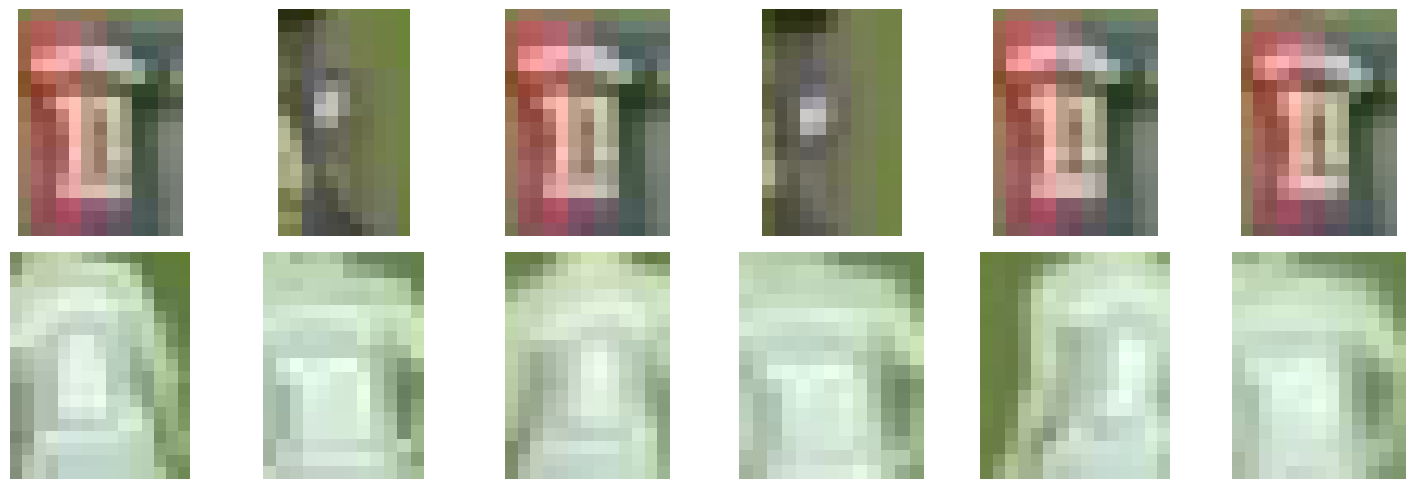

Eyeball check: each row should visually be one team's kit. If a row is mixed
(both kits present) or split by something else (motion blur, lighting), the
silhouette score above is telling the truth -- don't trust the numeric labels yet.


In [6]:
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(VIDEO_PATH)
samples_per_cluster = {0: [], 1: []}

for i, (frame_idx, track_id) in enumerate(calibration_meta):
    label = cluster_labels[i]
    if len(samples_per_cluster[label]) >= 6:
        continue
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        continue
    data = tracking_cache.get(frame_idx, {"tracks": []})
    bbox = next((t["bbox"] for t in data["tracks"] if t["track_id"] == track_id), None)
    if bbox is None:
        continue
    crop = get_torso_crop(frame, bbox)
    if crop is not None and crop.size > 0:
        samples_per_cluster[label].append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

    if len(samples_per_cluster[0]) >= 6 and len(samples_per_cluster[1]) >= 6:
        break

cap.release()

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for cluster_id in [0, 1]:
    for j, crop in enumerate(samples_per_cluster[cluster_id][:6]):
        axes[cluster_id][j].imshow(crop)
        axes[cluster_id][j].axis("off")
    axes[cluster_id][0].set_ylabel(f"Cluster {cluster_id}", fontsize=12)
plt.tight_layout()
plt.show()

print("Eyeball check: each row should visually be one team's kit. If a row is mixed")
print("(both kits present) or split by something else (motion blur, lighting), the")
print("silhouette score above is telling the truth -- don't trust the numeric labels yet.")


## Cell 7 — Classify every player detection per frame
Uses the same `scaler`/`kmeans` fit in Cell 5 on the real 768-dim SigLIP features (previously this silently picked up a stale 4-dim scaler from an out-of-order run and crashed with a feature-count mismatch). Raw per-frame team assignment, not smoothed yet -- that's the next cell.

In [7]:
raw_team_votes = defaultdict(lambda: defaultdict(int))
per_frame_team = {}

cap = cv2.VideoCapture(VIDEO_PATH)
frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % CLASSIFICATION_FRAME_STRIDE == 0:   # sparse sampling -- majority vote doesn't need every frame
        data = tracking_cache.get(frame_idx, {"tracks": []})
        for t in data["tracks"]:
            if t["track_id"] not in player_ids:
                continue
            feat = extract_siglip_embedding(frame, t["bbox"])
            if feat is None:
                continue
            scaled_feat = scaler.transform(feat.reshape(1, -1))
            team = int(kmeans.predict(scaled_feat)[0])
            raw_team_votes[t["track_id"]][team] += 1
            per_frame_team[(frame_idx, t["track_id"])] = team

    if frame_idx % 300 == 0:
        print(f"  frame {frame_idx}/{total_frames}")
    frame_idx += 1

cap.release()
print(f"\nClassified sampled frames for {len(raw_team_votes)} player tracks.")


  frame 0/3001
  frame 300/3001
  frame 600/3001
  frame 900/3001
  frame 1200/3001
  frame 1500/3001
  frame 1800/3001
  frame 2100/3001
  frame 2400/3001
  frame 2700/3001
  frame 3000/3001

Classified sampled frames for 20 player tracks.


[opus @ 0x1ea738c0] Error parsing Opus packet header.


## Cell 8 — Majority-vote smoothing: lock one team per track
Non-destructive -- `per_frame_team` keeps the raw noisy per-frame votes; `locked_team_by_id` holds the final decision, same pattern as class locking. Tracks below `WEAK_MAJORITY_THRESHOLD` are flagged for manual review.

In [8]:
locked_team_by_id = {}
for tid, votes in raw_team_votes.items():
    locked_team_by_id[tid] = max(votes, key=votes.get)

print("Locked team per player track:\n")
for tid in sorted(locked_team_by_id):
    votes = raw_team_votes[tid]
    total = sum(votes.values())
    majority_frac = votes[locked_team_by_id[tid]] / total
    flag = "  <-- weak majority, check this track" if majority_frac < WEAK_MAJORITY_THRESHOLD else ""
    print(f"  id={tid:2d} | team={locked_team_by_id[tid]} | votes={dict(votes)} "
          f"| majority={majority_frac:.2f}{flag}")

team0_count = sum(1 for t in locked_team_by_id.values() if t == 0)
team1_count = sum(1 for t in locked_team_by_id.values() if t == 1)
print(f"\nTeam 0: {team0_count} players | Team 1: {team1_count} players")


Locked team per player track:

  id= 3 | team=1 | votes={1: 333, 0: 23} | majority=0.94
  id= 4 | team=0 | votes={0: 323, 1: 1} | majority=1.00
  id= 5 | team=1 | votes={1: 323, 0: 19} | majority=0.94
  id= 6 | team=1 | votes={1: 255, 0: 4} | majority=0.98
  id= 8 | team=0 | votes={0: 358, 1: 6} | majority=0.98
  id= 9 | team=1 | votes={1: 122, 0: 2} | majority=0.98
  id=10 | team=0 | votes={0: 292, 1: 12} | majority=0.96
  id=11 | team=1 | votes={1: 196, 0: 1} | majority=0.99
  id=12 | team=0 | votes={1: 8, 0: 85} | majority=0.91
  id=13 | team=1 | votes={1: 92, 0: 3} | majority=0.97
  id=14 | team=1 | votes={1: 312, 0: 5} | majority=0.98
  id=15 | team=0 | votes={0: 203, 1: 4} | majority=0.98
  id=16 | team=0 | votes={0: 223, 1: 1} | majority=1.00
  id=17 | team=0 | votes={0: 9} | majority=1.00
  id=18 | team=1 | votes={1: 236, 0: 10} | majority=0.96
  id=19 | team=0 | votes={0: 108, 1: 2} | majority=0.98
  id=20 | team=0 | votes={0: 11} | majority=1.00
  id=21 | team=1 | votes={1: 2

## Cell 9 — Assign goalkeepers via pitch-space centroid proximity
For each goalkeeper track, compute its average pitch-space position, and the average pitch-space position of each team's players. Assign the goalkeeper to whichever team centroid is closer. Uses pitch coordinates (via homography), not raw pixel distance -- pixel-space distance is distorted by camera perspective.

In [9]:
def project_to_pitch(point_px, H):
    pt = cv2.perspectiveTransform(
        np.array([[[point_px[0], point_px[1]]]], dtype=np.float32), H
    ).reshape(2)
    return float(pt[0] / PX_PER_METER), float(pt[1] / PX_PER_METER)


def bbox_foot_point(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1 + x2) / 2, y2)


def get_track_positions(track_id, cache=tracking_cache, sample_stride=10):
    '''Pitch-space positions for a track, sampled every sample_stride frames it appears in.'''
    positions = []
    for frame_idx, data in cache.items():
        if frame_idx % sample_stride != 0:
            continue
        for t in data["tracks"]:
            if t["track_id"] == track_id:
                H = get_homography(frame_idx)
                if H is not None:
                    pos = project_to_pitch(bbox_foot_point(t["bbox"]), H)
                    positions.append(pos)
                break
    return positions


goalkeeper_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "goalkeeper"}
print(f"Goalkeeper tracks to assign: {sorted(goalkeeper_ids)}")

# team centroids, from locked player positions
team_positions = {0: [], 1: []}
for tid, team in locked_team_by_id.items():
    team_positions[team].extend(get_track_positions(tid))

team_centroids = {
    team: np.mean(positions, axis=0) if positions else None
    for team, positions in team_positions.items()
}
print(f"\nTeam 0 centroid (pitch m): {team_centroids[0]}")
print(f"Team 1 centroid (pitch m): {team_centroids[1]}")

goalkeeper_team_assignment = {}
for gk_id in goalkeeper_ids:
    gk_positions = get_track_positions(gk_id)
    if not gk_positions:
        print(f"  id={gk_id}: no valid pitch positions found -- skipping")
        continue
    gk_centroid = np.mean(gk_positions, axis=0)

    dist0 = np.linalg.norm(gk_centroid - team_centroids[0]) if team_centroids[0] is not None else np.inf
    dist1 = np.linalg.norm(gk_centroid - team_centroids[1]) if team_centroids[1] is not None else np.inf

    assigned_team = 0 if dist0 < dist1 else 1
    goalkeeper_team_assignment[gk_id] = assigned_team
    print(f"  id={gk_id} | pitch pos: ({gk_centroid[0]:.1f}, {gk_centroid[1]:.1f})m "
          f"| dist_to_team0={dist0:.1f}m dist_to_team1={dist1:.1f}m -> team {assigned_team}")


Goalkeeper tracks to assign: [24, 26]

Team 0 centroid (pitch m): [54.56114468 29.82244505]
Team 1 centroid (pitch m): [61.05083961 30.77425758]
  id=24 | pitch pos: (11.6, 32.1)m | dist_to_team0=43.1m dist_to_team1=49.5m -> team 0
  id=26 | pitch pos: (91.3, 33.1)m | dist_to_team0=36.9m dist_to_team1=30.4m -> team 1


## Cell 10 — Merge and save final team assignment cache

In [10]:
final_team_by_id = dict(locked_team_by_id)
final_team_by_id.update(goalkeeper_team_assignment)

# referees are intentionally excluded -- they have no team
referee_ids = {tid for tid, cls in locked_class_by_id.items() if cls == "referee"}
print(f"Referee tracks (no team assigned): {sorted(referee_ids)}")

with open(OUTPUT_TEAM_CACHE_PATH, "wb") as f:
    pickle.dump({
        "team_by_id": final_team_by_id,
        "raw_team_votes": dict(raw_team_votes),
        "goalkeeper_team_assignment": goalkeeper_team_assignment,
        "team_centroids": team_centroids,
    }, f)

print(f"\nFinal team assignment ({len(final_team_by_id)} tracks):")
for tid in sorted(final_team_by_id):
    role = locked_class_by_id.get(tid, "?")
    print(f"  id={tid:2d} | {role:10s} | team={final_team_by_id[tid]}")

print(f"\nSaved to {OUTPUT_TEAM_CACHE_PATH}")


Referee tracks (no team assigned): [1, 2, 7]

Final team assignment (22 tracks):
  id= 3 | player     | team=1
  id= 4 | player     | team=0
  id= 5 | player     | team=1
  id= 6 | player     | team=1
  id= 8 | player     | team=0
  id= 9 | player     | team=1
  id=10 | player     | team=0
  id=11 | player     | team=1
  id=12 | player     | team=0
  id=13 | player     | team=1
  id=14 | player     | team=1
  id=15 | player     | team=0
  id=16 | player     | team=0
  id=17 | player     | team=0
  id=18 | player     | team=1
  id=19 | player     | team=0
  id=20 | player     | team=0
  id=21 | player     | team=1
  id=22 | player     | team=0
  id=23 | player     | team=1
  id=24 | goalkeeper | team=0
  id=26 | goalkeeper | team=1

Saved to barca_atletico_team_assignment.pkl


## Cell 11 — Annotate video (optional visual check)

In [11]:
OUTPUT_VIDEO_PATH_ = OUTPUT_VIDEO_PATH

TEAM_COLORS = {
    0: (255, 120, 0),     # blue-ish (BGR) -- team 0
    1: (0, 60, 220),      # red-ish (BGR)  -- team 1
}
GOALKEEPER_COLOR = (0, 165, 255)   # orange
REFEREE_COLOR = (40, 40, 230)      # red marker (distinct from team colors above)
BALL_COLOR = (0, 220, 255)
BALL_LOW_CONF_COLOR = (0, 140, 200)


def draw_pill_label(frame, text, x, y, color):
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), _ = cv2.getTextSize(text, font, 0.5, 1)
    x1, y1 = int(x), int(y - th - 8)
    x2, y2 = int(x + tw + 12), int(y)
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, -1, cv2.LINE_AA)
    cv2.putText(frame, text, (x1 + 6, y2 - 4), font, 0.5, (255, 255, 255), 1, cv2.LINE_AA)


cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH_, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    data = tracking_cache.get(frame_idx, {"ball": None, "tracks": []})

    for t in data["tracks"]:
        tid = t["track_id"]
        role = locked_class_by_id.get(tid, t["class"])
        x1, y1, x2, y2 = [int(v) for v in t["bbox"]]

        if role == "referee":
            color = REFEREE_COLOR
            label = f"#{tid} REF"
        elif role == "goalkeeper":
            color = GOALKEEPER_COLOR
            team = final_team_by_id.get(tid)
            label = f"#{tid} GK-T{team}" if team is not None else f"#{tid} GK"
        else:
            team = final_team_by_id.get(tid, -1)
            color = TEAM_COLORS.get(team, (200, 200, 200))
            label = f"#{tid} T{team}"

        if role == "goalkeeper":
            cx, cy = (x1 + x2) // 2, y2
            cv2.ellipse(frame, (cx, cy), (int((x2 - x1) * 0.5), 8), 0, 0, 360, color, 3, cv2.LINE_AA)
        else:
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)

        draw_pill_label(frame, label, x1, y1, color)

    if data.get("ball") is not None:
        bx1, by1, bx2, by2 = [int(v) for v in data["ball"]["bbox"]]
        cx, cy = (bx1 + bx2) // 2, (by1 + by2) // 2
        r = max((bx2 - bx1) // 2, 4)
        low_conf = data["ball"].get("low_confidence", False)
        color = BALL_LOW_CONF_COLOR if low_conf else BALL_COLOR
        cv2.circle(frame, (cx, cy), r, color, 2 if not low_conf else 1, cv2.LINE_AA)

    writer.write(frame)
    if frame_idx % 200 == 0:
        print(f"rendered {frame_idx}/{total}")
    frame_idx += 1

cap.release()
writer.release()
print(f"\nDone. Saved annotated video to {OUTPUT_VIDEO_PATH_}")


rendered 0/3001
rendered 200/3001
rendered 400/3001
rendered 600/3001
rendered 800/3001
rendered 1000/3001
rendered 1200/3001
rendered 1400/3001
rendered 1600/3001
rendered 1800/3001
rendered 2000/3001
rendered 2200/3001
rendered 2400/3001
rendered 2600/3001
rendered 2800/3001
rendered 3000/3001

Done. Saved annotated video to barca_atletico_team_annotated.mp4


[opus @ 0x1de72c40] Error parsing Opus packet header.
